![Autistic](https://images.indianexpress.com/2018/03/autism-759.jpg)

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">📋 TABLE OF CONTENTS</p>   


* [1. Importing Libraries](#1)
    
* [2. Reading Data](#2)
    
* [3. Feature Description](#3)
    
* [4. Meta Information of Dataframe](#4)
    
    * [4.1- Shape of Dataframe](#4.1)
    
    * [4.2- Datatype of Each feature](#4.2)
    
    
* [5. Statistical information of data](#5) 
    
* [6. Checking for NaN values](#6)
    
    * [6.1 Imputing NaN values in `Age`](#6.1)
   
    
* [7. Checking unique values in Categorical features](#7)
    
    * [7.1 Replacing invalid value in `ethnicity`](#7.1)
    
    * [7.2 Replacing invalid value in `relation`](#7.2)
    

* [8. Visualization](#8)
    
    * [8.1 Counts of Males and Females in Data](#8.1)
    
    * [8.2 Autism Spectrum Disorder Counts](#8.2)
    
    * [8.3 Average age of Males and Females](#8.3)
    
    * [8.4 Gender Counts of ASD Patients](#8.4)
    
    * [8.5 Counts of ASD Patients Country Wise](#8.5)
    
    
    
* [9. Preprocessing data for Classification model](#9)
    
    * [9.1 Dropping Unwanted columns](#9.1)
    
    * [9.2 Splitting Data in X and Y](#9.2)
    
    * [9.3 OneHotEncoding of Categorical features](#9.3)
    
    * [9.4 Splitting data in Train and Test](#9.4)
    
    
* [10 Creating ANN Model](#10)
    
    * [10.1 Compiling Model](#10.1)
    
    * [10.2 Summary of Model](#10.2)
    
    * [10.3 Visualizing Model Layers](#10.3)
    
    * [10.4 Training Model](#10.4)
    
* [11 Visualize Model Accuracy & Loss](#11)
    
* [12 Evaluating Model](#12)
    
* [13 Confusion Matrix](#13)
    
* [14 Classification Report](#14)
    
* [15 End](#15)
    

    
    
    

    
    
    
    


    
    
    
    
    
    
    
   
    
    
    
    
    
    
    
    
    

<a id="1"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Importing Libraries</p>


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

sns.set_style("darkgrid")
pd.set_option("display.max_columns", None)   # setting to display all columns
pd.options.plotting.backend = "plotly"

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/autism-screening-on-adults/autism_screening.csv


<a id="2"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Reading Data</p>

In [2]:
df = pd.read_csv("/kaggle/input/autism-screening-on-adults/autism_screening.csv")

df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26.0,f,White-European,no,no,United States,no,6.0,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,24.0,m,Latino,no,yes,Brazil,no,5.0,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,27.0,m,Latino,yes,yes,Spain,no,8.0,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,35.0,f,White-European,no,yes,United States,no,6.0,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,40.0,f,?,no,no,Egypt,no,2.0,18 and more,?,NO


<a id="3"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Features Description</p>

|Feature | Description
|------|------------
| index | The participant’s ID number
|AX_Score|Score based on the Autism Spectrum Quotient (AQ) 10 item screening tool [AQ-10](https://docs.autismresearchcentre.com/tests/AQ10.pdf)
|age|Age in years
|gender| Male or Female
|ethnicity|Ethnicities in text form
|jaundice|Whether or not the participant was born with jaundice?
|autism|Whether or not anyone in tbe immediate family has been diagnosed with autism?
|country_of_res|Countries in text format
|used_app_before|Whether the participant has used a screening app
|result|Score from the AQ-10 screening tool
|age_desc|Age as categorical
|relation|Relation of person who completed the test
|Class/ASD|Participant classification


<a id="4"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Meta information of dataframe</p>

<a id="4.1"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Shape of DataFrame</p>

In [3]:
print(f'Shape of dataframe is: {df.shape}')

Shape of dataframe is: (704, 21)


<a id="4.2"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Datatype of Each Feature</p>

In [4]:
pd.DataFrame(df.dtypes,
             columns = ["Data Type"])

,Data Type
A1_Score,int64
A2_Score,int64
A3_Score,int64
A4_Score,int64
A5_Score,int64
A6_Score,int64
A7_Score,int64
A8_Score,int64
A9_Score,int64
A10_Score,int64


<a id="5"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Statistical information of data</p>

In [5]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,702.000000,704.000000
mean,0.721591,0.453125,0.457386,0.495739,0.498580,0.284091,0.417614,0.649148,0.323864,0.573864,29.698006,4.875000
std,0.448535,0.498152,0.498535,0.500337,0.500353,0.451301,0.493516,0.477576,0.468281,0.494866,16.507465,2.501493
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,3.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,27.000000,4.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.000000,7.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,383.000000,10.000000


<a id="6"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Checking for NaN values</p>

In [6]:
pd.DataFrame(df.isnull().sum(), columns=["Missing Values"]).style.bar(color = "#84A9AC")

,Missing Values
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0
A10_Score,0


**Only `age` feature has 2 missing values**

In [7]:
print(f"Maximum age is data: {df['age'].max()}\n")

print(f"Minimum age is data: {df['age'].min()}")

Maximum age is data: 383.0

Minimum age is data: 17.0


**383 age is outlier so dropping it**

<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Record which has maximum value in Age</p>

In [8]:
df[df['age'] == df['age'].max()]

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
52,1,0,0,0,0,0,0,0,0,0,383.0,f,Pasifika,no,no,New Zealand,no,1.0,18 and more,Self,NO


In [9]:
# dropping record number 52
df.drop(index = 52, inplace = True)

# resetting index
df.reset_index(inplace = True)

<a id="6.1"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Imputing NaN values in age with mean of age</p>


In [10]:
df['age'] = df['age'].fillna(np.round(df['age'].mean(), 0))

In [11]:
pd.DataFrame(df.isnull().sum(), columns=["Missing Values"])

,Missing Values
index,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0


**Missing values are now imputed**

<a id="7"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Checking unique values in Categorical feature</p>

In [12]:
for col in df.select_dtypes('O').columns:
    print("-------------------------------")
    print(f'Column name: {col}\n')
    print(f'Unique values:\n{df[col].unique()}\n\n')

-------------------------------
Column name: gender

Unique values:
['f' 'm']


-------------------------------
Column name: ethnicity

Unique values:
['White-European' 'Latino' '?' 'Others' 'Black' 'Asian' 'Middle Eastern '
 'Pasifika' 'South Asian' 'Hispanic' 'Turkish' 'others']


-------------------------------
Column name: jundice

Unique values:
['no' 'yes']


-------------------------------
Column name: austim

Unique values:
['no' 'yes']


-------------------------------
Column name: contry_of_res

Unique values:
['United States' 'Brazil' 'Spain' 'Egypt' 'New Zealand' 'Bahamas'
 'Burundi' 'Austria' 'Argentina' 'Jordan' 'Ireland' 'United Arab Emirates'
 'Afghanistan' 'Lebanon' 'United Kingdom' 'South Africa' 'Italy'
 'Pakistan' 'Bangladesh' 'Chile' 'France' 'China' 'Australia' 'Canada'
 'Saudi Arabia' 'Netherlands' 'Romania' 'Sweden' 'Tonga' 'Oman' 'India'
 'Philippines' 'Sri Lanka' 'Sierra Leone' 'Ethiopia' 'Viet Nam' 'Iran'
 'Costa Rica' 'Germany' 'Mexico' 'Russia' 'Armenia' 'I

**`ethnicity` and `relation` contains some invalid values**

<a id="7.1"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Replacing invalid value in ethnicity</p>


In [13]:
df['ethnicity'] = df['ethnicity'].replace('?', 'Others')

**In `ethnicity` feature, "Others" and "others" are same thing but it is considered different because one is in small case and other is in letter case. So fixing this.**

In [14]:
df['ethnicity'] = df['ethnicity'].replace('others', 'Others')

**Checking unique values in `ethnicity` after fixing problems**

In [15]:
df['ethnicity'].unique()

array(['White-European', 'Latino', 'Others', 'Black', 'Asian',
       'Middle Eastern ', 'Pasifika', 'South Asian', 'Hispanic',
       'Turkish'], dtype=object)

<a id="7.2"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Replacing invalid value in relation</p>


**Replacing `?` in `relation` with mode of relation**

In [16]:
df['relation'] = df['relation'].replace('?', df['relation'].mode()[0])

**Checking unique values in `relation` after fixing problems**

In [17]:
df['relation'].unique()

array(['Self', 'Parent', 'Health care professional', 'Relative', 'Others'],
      dtype=object)

<a id="8"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Visualization</p>

<a id="8.1"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Counts of Males to Females in dataset</p>


In [18]:
fig = px.histogram(df, x="gender",                   
                   template='plotly_dark',
                   color_discrete_sequence = ["#84A9AC"])

fig.update_layout(title = "<b>Counts of Male and Female</b>",
                  title_x = 0.5,
                  title_font = dict(size = 20),
                  uniformtext_minsize = 15)

fig.show()

In [19]:
fig = px.pie(df, names = "gender",
             title = "<b>Counts of Male and Female</b>",
             hole = 0.5, template = "plotly_dark")

fig.update_traces(textposition='inside',
                  textinfo='percent+label',
                  marker=dict(line=dict(color='#000000', width = 1.5)))

fig.update_layout(title_x = 0.5,
                  title_font = dict(size = 20),
                  uniformtext_minsize = 15)


fig.show()

<a id="8.2"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Autism Spectrum Disorder Counts</p>


In [20]:
df['Class/ASD'].value_counts()

NO     514
YES    189
Name: Class/ASD, dtype: int64

In [21]:
fig = px.pie(df, names = "Class/ASD",
             title = "<b>Autism Spectrum Disorder Counts</b>",
             template = "plotly_dark")

fig.update_traces(textposition='inside',
                  textinfo = 'percent+label',
                  marker = dict(line = dict(color = '#000000', width = 1.5)))

fig.update_layout(title_x = 0.5,
                  title_font = dict(size = 20),
                  uniformtext_minsize = 15)


fig.show()

#### **27% people are ASD patient in dataset**

<a id="8.3"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Average age of males and females</p>


In [22]:
fig = df.groupby('gender').agg({'age':'mean'}).plot(kind='bar',                                                    
                                                    template = "seaborn",
                                                    labels = {"gender":"Gender",
                                                              "value":"Age"},
                                                    color_discrete_sequence = ["#84b1b5"]);

fig.update_layout(title = "<b>Average Age</b>\n",
                  title_font = dict(size = 20),)


fig.show()

<a id="8.4"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Gender Counts of ASD Patients</p>


In [23]:
fig = df[df['Class/ASD'] == "YES"]['gender'].value_counts().plot(kind = 'bar',                                                               
                                                                 template = "seaborn",
                                                                 color_discrete_sequence = ["#84b1b5"],
                                                                 labels = {"index":"Gender",
                                                                          "value":"Counts"});

fig.update_layout(title = "<b>Gender Count of ASD Patients</b>\n",
                  title_font = dict(size = 20), width = 900)

fig.show()

<a id="8.5"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Counts of ASD Patients Country Wise</p>


In [24]:
asd_patients_country_wise = pd.DataFrame(df[df['Class/ASD'] == "YES"]['contry_of_res'].value_counts()).rename({"contry_of_res":"ASD_Patient_Counts"}, axis = 1)

In [25]:
asd_patients_country_wise.style.bar(color="#84A9AC") 

,ASD_Patient_Counts
United States,53
United Kingdom,29
New Zealand,15
Australia,12
Canada,10
India,6
France,5
Brazil,5
Malaysia,4
Mexico,4


In [26]:
asd_patients_country_wise.index

Index(['United States', 'United Kingdom', 'New Zealand', 'Australia', 'Canada',
       'India', 'France', 'Brazil', 'Malaysia', 'Mexico', 'Italy',
       'Netherlands', 'Austria', 'Russia', 'United Arab Emirates', 'Sweden',
       'Afghanistan', 'Germany', 'Ireland', 'South Africa', 'Jordan', 'Spain',
       'Uruguay', 'Nepal', 'Finland', 'AmericanSamoa', 'Pakistan', 'Belgium',
       'Viet Nam', 'Argentina', 'Saudi Arabia', 'Bangladesh', 'Romania',
       'Sierra Leone', 'China', 'Bahamas', 'Cyprus'],
      dtype='object')

In [27]:
fig = px.bar(data_frame = asd_patients_country_wise, 
             x = asd_patients_country_wise.index,    
             y = "ASD_Patient_Counts",
             labels = {"index" : "Country"},     
             color_discrete_sequence = px.colors.qualitative.D3_r,
             template='plotly_dark')

fig.update_xaxes(tickangle = 310)

fig.update_layout(title={
        'text': "<b>Counts of ASD Patients Country Wise</b>",
        'y':0.93,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})

fig.show()


In [28]:
label = asd_patients_country_wise.index
value = asd_patients_country_wise['ASD_Patient_Counts']

fig = go.Figure(data=[go.Pie(labels = label,
                             values = value,
                             rotation = 90)])

fig.update_traces(textposition = 'inside',
                  textinfo = 'percent+label',
                  marker = dict(line = dict(color = '#000000', width = 1.5)))

fig.update_layout(title_text='<b>Country Wise Counts of ASD Patients</b>',
                  title_x = 0.5,
                  title_font = dict(size = 20),
                  uniformtext_minsize = 15,
                  template='plotly_dark')

fig.show()

<a id="9"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Preprocessing data for Classification model</p>

<a id="9.1"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Dropping Unwanted columns</p>


In [29]:
df.drop(['index','age_desc'], axis = 1, inplace = True)

<a id="9.2"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Splitting data in X and Y</p>


In [30]:
X = df.drop("Class/ASD", axis = 1)    # select all other feature except "Class/ASD" for training
Y = df['Class/ASD']

<a id="9.3"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">OneHotEncoding of Categorical features</p>


In [31]:
X = pd.get_dummies(X)
Y = pd.get_dummies(Y)

<a id="9.4"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Splitting data in train and test</p>


In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25)

In [33]:
print(f"Shape of X_train is: {X_train.shape}")
print(f"Shape of Y_train is: {Y_train.shape}\n")
print(f"Shape of X_test is: {X_test.shape}")
print(f"Shape of Y_test is: {Y_test.shape}")

Shape of X_train is: (527, 102)
Shape of Y_train is: (527, 2)

Shape of X_test is: (176, 102)
Shape of Y_test is: (176, 2)


<a id="10"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Creating ANN Model</p>

In [34]:
input_dim = X.shape[1]

In [35]:
model = Sequential()
model.add(Dense(8, input_dim = input_dim, kernel_initializer='normal', activation='relu'))
model.add(Dense(5, activation = "relu", kernel_initializer='normal'))
model.add(Dense(2, activation = 'sigmoid'))


User settings:

   KMP_AFFINITY=granularity=fine,verbose,compact,1,0
   KMP_BLOCKTIME=0
   KMP_DUPLICATE_LIB_OK=True
   KMP_INIT_AT_FORK=FALSE
   KMP_SETTINGS=1
   KMP_WARNINGS=0

Effective settings:

   KMP_ABORT_DELAY=0
   KMP_ADAPTIVE_LOCK_PROPS='1,1024'
   KMP_ALIGN_ALLOC=64
   KMP_ALL_THREADPRIVATE=128
   KMP_ATOMIC_MODE=2
   KMP_BLOCKTIME=0
   KMP_CPUINFO_FILE: value is not defined
   KMP_DETERMINISTIC_REDUCTION=false
   KMP_DEVICE_THREAD_LIMIT=2147483647
   KMP_DISP_NUM_BUFFERS=7
   KMP_DUPLICATE_LIB_OK=true
   KMP_ENABLE_TASK_THROTTLING=true
   KMP_FORCE_REDUCTION: value is not defined
   KMP_FOREIGN_THREADS_THREADPRIVATE=true
   KMP_FORKJOIN_BARRIER='2,2'
   KMP_FORKJOIN_BARRIER_PATTERN='hyper,hyper'
   KMP_GTID_MODE=3
   KMP_HANDLE_SIGNALS=false
   KMP_HOT_TEAMS_MAX_LEVEL=1
   KMP_HOT_TEAMS_MODE=0
   KMP_INIT_AT_FORK=true
   KMP_LIBRARY=throughput
   KMP_LOCK_KIND=queuing
   KMP_MALLOC_POOL_INCR=1M
   KMP_NUM_LOCKS_IN_BLOCK=1
   KMP_PLAIN_BARRIER='2,2'
   KMP_PLAIN_BARRIER_P

<a id="10.1"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Compiling Model</p>


In [36]:
# compiling model
model.compile(optimizer = Adam(learning_rate = 0.001),
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

<a id="10.2"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Checking summary of Model</p>


In [37]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 8)                 824       
_________________________________________________________________
dense_1 (Dense)              (None, 5)                 45        
_________________________________________________________________
dense_2 (Dense)              (None, 2)                 12        
Total params: 881
Trainable params: 881
Non-trainable params: 0
_________________________________________________________________


<a id="10.3"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Visualizing Model Layers</p>


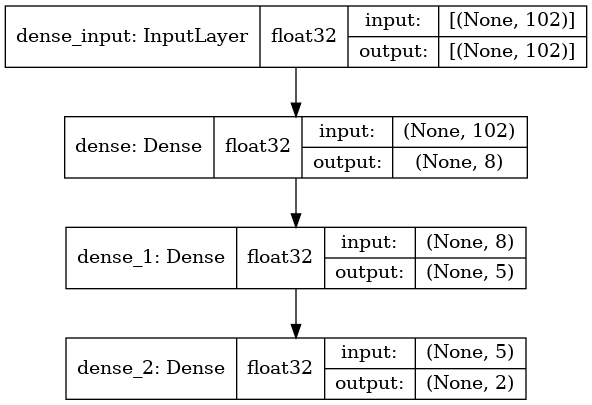

In [38]:
plot_model(model,
           show_dtype = True,
           show_layer_names = True,
           show_shapes = True)

<a id="10.4"></a>
<p style="background-color:#84A9AC;font-family:newtimeroman;color:#FFF9ED;font-size:120%;text-align:center;border-radius:20px 80px;">Training Model</p>


In [39]:
result = model.fit(X_train, Y_train, epochs = 20, batch_size = 10)

2021-10-30 13:03:28.371791: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/20
53/53 [==============================] - 1s 2ms/step - loss: 0.6858 - accuracy: 0.6983
Epoch 2/20
53/53 [==============================] - 0s 2ms/step - loss: 0.6583 - accuracy: 0.7249
Epoch 3/20
53/53 [==============================] - 0s 2ms/step - loss: 0.6069 - accuracy: 0.7287
Epoch 4/20
53/53 [==============================] - 0s 2ms/step - loss: 0.5359 - accuracy: 0.8008
Epoch 5/20
53/53 [==============================] - 0s 2ms/step - loss: 0.4466 - accuracy: 0.8899
Epoch 6/20
53/53 [==============================] - 0s 2ms/step - loss: 0.3599 - accuracy: 0.9260
Epoch 7/20
53/53 [==============================] - 0s 2ms/step - loss: 0.2953 - accuracy: 0.9507
Epoch 8/20
53/53 [==============================] - 0s 2ms/step - loss: 0.2456 - accuracy: 0.9507
Epoch 9/20
53/53 [==============================] - 0s 2ms/step - loss: 0.2134 - accuracy: 0.9469
Epoch 10/20
53/53 [==============================] - 0s 2ms/step - loss: 0.1879 - accuracy: 0.9564
Epoch 11/20
53/53 [

<a id="11"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Visualize Model Accuracy & Loss</p>


In [40]:
acc = result.history['accuracy']
loss = result.history['loss']

epoch = [i + 1 for i in range(len(acc))]

In [41]:
acc_loss_df = pd.DataFrame({"Accuracy" : acc,
                            "Loss" : loss,
                            "Epoch" : epoch})

acc_loss_df.style.bar(color = '#84A9AC',
                      subset = ['Accuracy','Loss'])

,Accuracy,Loss,Epoch
0,0.698292,0.685775,1
1,0.724858,0.658343,2
2,0.728653,0.606899,3
3,0.800759,0.535896,4
4,0.889943,0.446556,5
5,0.925996,0.359915,6
6,0.950664,0.295316,7
7,0.950664,0.245575,8
8,0.946869,0.213379,9
9,0.956357,0.187929,10


In [42]:
fig = go.Figure()

fig.add_trace(go.Scatter(x = acc_loss_df['Epoch'],
                         y = acc_loss_df['Accuracy'],
                         mode='lines+markers',
                         name='Accuracy'))

fig.add_trace(go.Scatter(x = acc_loss_df['Epoch'],
                         y = acc_loss_df['Loss'],
                         mode='lines+markers',
                         name = 'Loss'))

fig.update_layout(title = {'text': "<b>Training Accuracy Vs Training Loss</b>\n",
                           'xanchor': 'center',
                           'yanchor': 'top',
                           'y':0.9,'x':0.5,},
                  xaxis_title="Epoch",
                  yaxis_title = "Accuracy / Loss",
                  title_font = dict(size = 20))

fig.layout.template = 'plotly_dark'

fig.show()

<a id="12"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Evaluating Model</p>


In [43]:
loss, acc = model.evaluate(X_test, Y_test)

6/6 [==============================] - 0s 2ms/step - loss: 0.1429 - accuracy: 0.9375


In [44]:
print(f"Accuracy on unseen data is: { np.round(acc, 2) }")
print(f'Loss on unseen data is: { np.round(loss, 2) }')

Accuracy on unseen data is: 0.94
Loss on unseen data is: 0.14


<a id="13"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Classification Report</p>

In [45]:
prediction = model.predict(X_test)
prediction = np.argmax(prediction, axis = 1)

In [46]:
print(accuracy_score(Y_test[['YES']], prediction))

0.9375


In [47]:
print(classification_report(Y_test[['YES']], prediction))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       132
           1       0.88      0.86      0.87        44

    accuracy                           0.94       176
   macro avg       0.92      0.91      0.92       176
weighted avg       0.94      0.94      0.94       176



<a id="15"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:130%;text-align:center;border-radius:10px 10px;">I Hope you like this kernel. If so, don't forget to Upvote 😊</p>